# 로지스틱 회귀
- 이진 분류 문제에서 클래스 확률을 예측

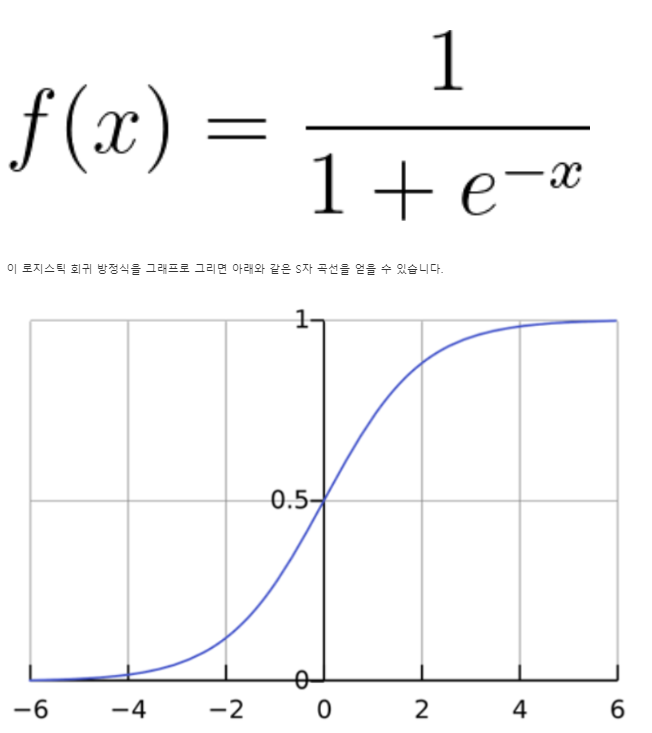

In [1]:
import pandas as pd

fish = pd.read_csv('fish.csv')
fish.head()                         #  최상위 5개만 출력

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [3]:
fish.tail()         # 맨 뒤의 데이터 5개

,Species,Weight,Length,Diagonal,Height,Width
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,15.0,16.2,2.9322,1.8792


In [4]:
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [5]:
fish.corr()                 # 상관계수 (두 변수의 상관성 -1 ~ 1)

,Weight,Length,Diagonal,Height,Width
Weight,1.000000,0.918618,0.923044,0.724345,0.886507
Length,0.918618,1.000000,0.994103,0.640441,0.873547
Diagonal,0.923044,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.873547,0.878520,0.792881,1.000000


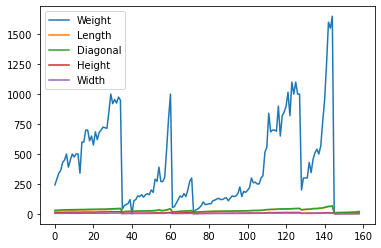

In [6]:
fish.plot()

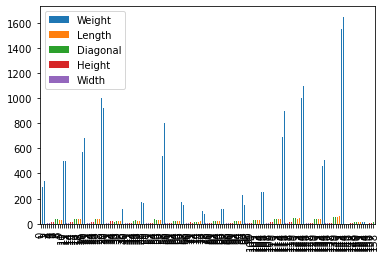

In [7]:
fish.plot(kind='bar')

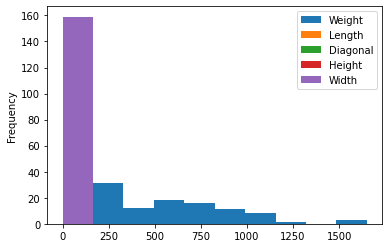

In [8]:
fish.plot(kind='hist')

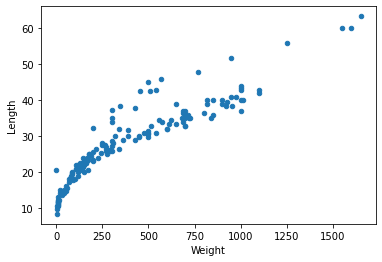

In [9]:
fish.plot(kind='scatter', x='Weight', y='Length')

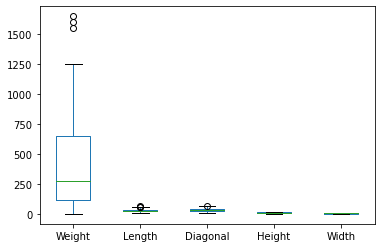

In [10]:
fish.plot(kind='box')

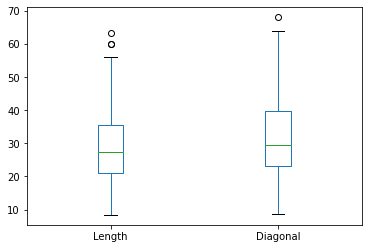

In [11]:
fish[['Length', 'Diagonal']].plot(kind='box')

In [12]:
# 표준점수 = (값 - 평균) / 표준편차
fish = fish.assign(Weight = lambda x: x.Weight.sub(x.Weight.mean()).div(x.Weight.std()))
fish = fish.assign(Length = lambda x: x.Length.sub(x.Length.mean()).div(x.Length.std()))
fish = fish.assign(Diagonal = lambda x: x.Diagonal.sub(x.Diagonal.mean()).div(x.Diagonal.std()))
fish = fish.assign(Height = lambda x: x.Height.sub(x.Height.mean()).div(x.Height.std()))
fish = fish.assign(Width = lambda x: x.Width.sub(x.Width.mean()).div(x.Width.std()))

fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,-0.436692,-0.281414,-0.105686,0.594700,-0.235784
1,Bream,-0.302606,-0.197430,-0.002329,0.818674,-0.066369
2,Bream,-0.162933,-0.178767,-0.010942,0.794830,0.165271
3,Bream,-0.098683,0.054522,0.195772,0.877001,0.022550
4,Bream,0.088479,0.054522,0.238837,0.810275,0.425028


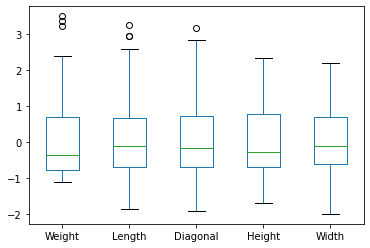

In [13]:
fish.plot(kind='box')

In [14]:
import pandas as pd

fish = pd.read_csv('fish.csv')
fish.head()                         #  최상위 5개만 출력

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [15]:
# 해당 컬럼에 몇가지 종류의 값이 있니
fish['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [16]:
# 몇 가지 종류니? 갯수
fish['Species'].nunique()

7

In [17]:
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [18]:
# 학습을 위해 numpy 배열로 입력 데이터를 만든다
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
print(fish_input[:5])
print(fish_input.shape)

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]
(159, 5)


In [19]:
# 학습을 위해 numpy 배열로 타겟 데이터를 만든다
fish_target = fish['Species'].to_numpy()
print(fish_target[:5])
print(fish_target.shape)

['Bream' 'Bream' 'Bream' 'Bream' 'Bream']
(159,)


In [20]:
# 훈련과 테스트 데이터를 분할한다
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(fish_input, fish_target, random_state=42)

In [21]:
print(train_input.shape)
print(test_input.shape)

(119, 5)
(40, 5)


In [22]:
# 표준화 처리
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [23]:
print(train_input[:5])
print(train_scaled[:5])

[[720.      35.      40.6     16.3618   6.09  ]
 [500.      45.      48.       6.96     4.896 ]
 [  7.5     10.5     11.6      1.972    1.16  ]
 [110.      22.      23.5      5.5225   3.995 ]
 [140.      20.7     23.2      8.5376   3.2944]]
[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [ 0.30041219  1.54653445  1.45316551 -0.46981663  0.27291745]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [-0.79734143 -0.60880176 -0.67486907 -0.82480589 -0.27631471]
 [-0.71289885 -0.73062511 -0.70092664 -0.0802298  -0.7033869 ]]


## k-최근접 이웃 분류기의 확률 예측

In [24]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [25]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [26]:
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [27]:
#확률 값 확인
import numpy as np

proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


## k-최근접 이웃 알고리즘의 확률

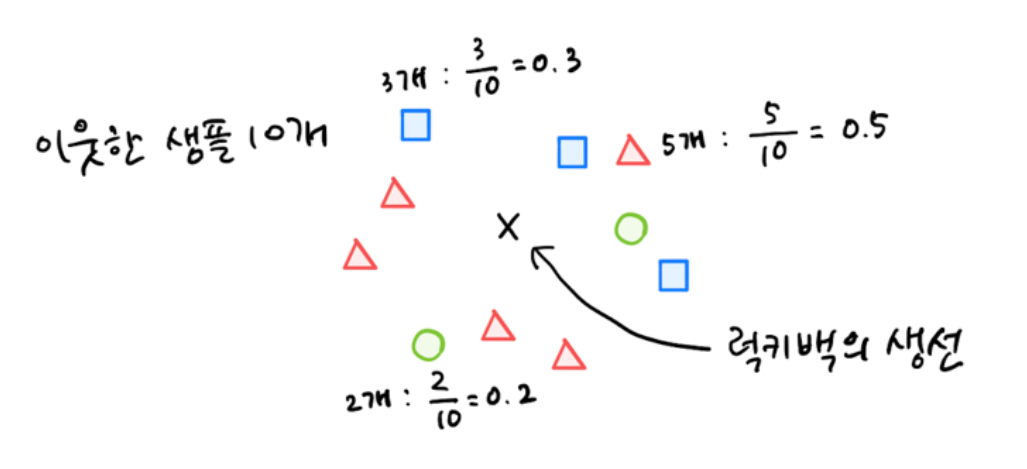

## 로지스틱 회귀(Logistic Regression)

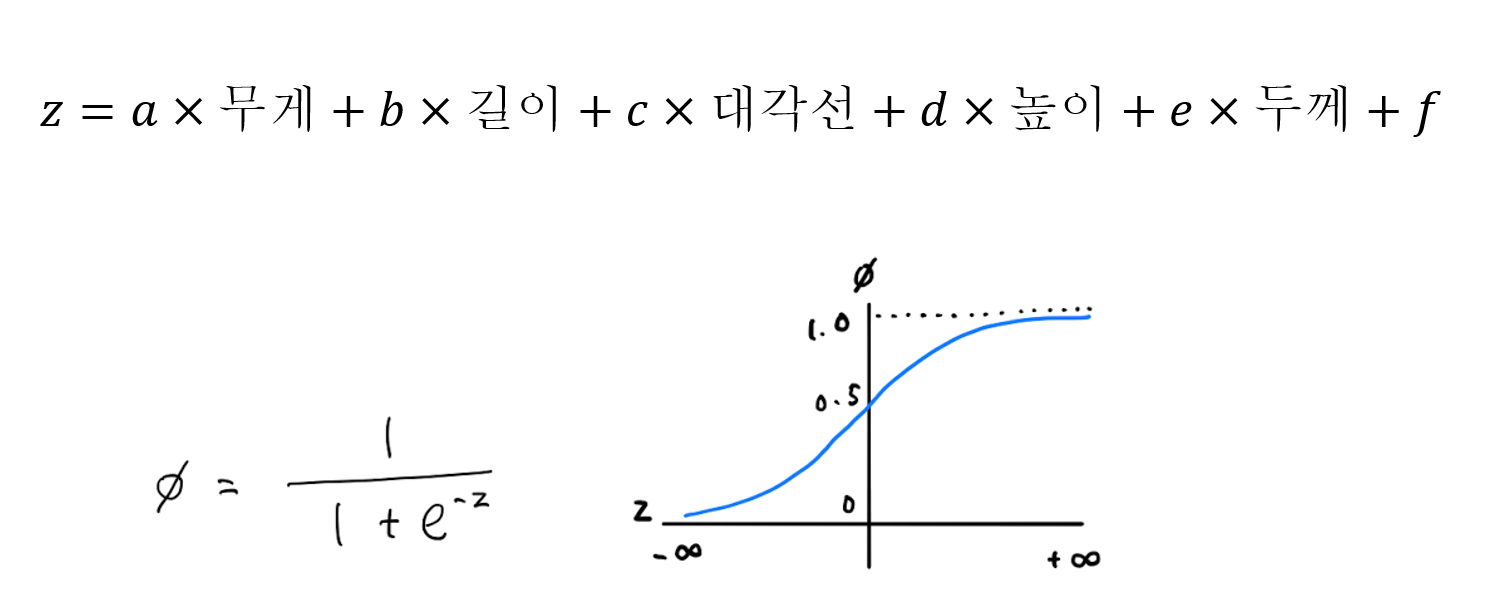

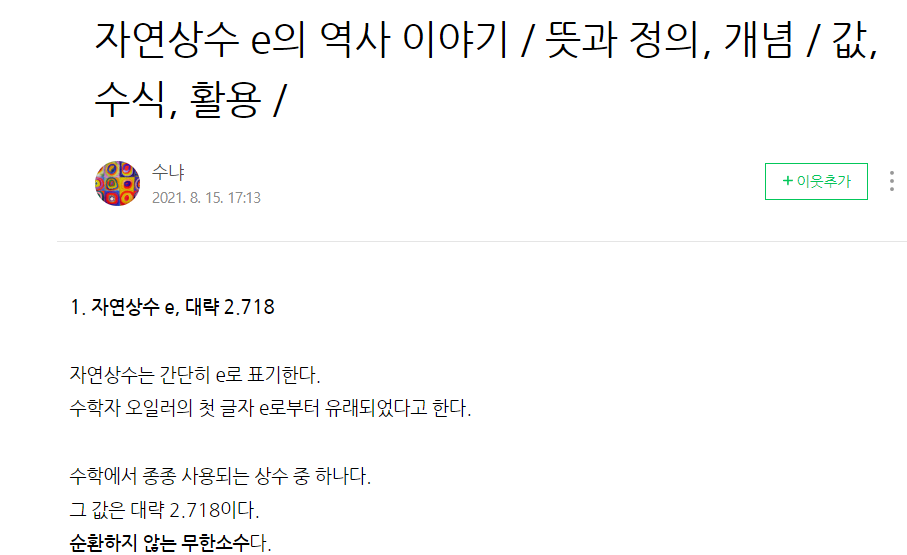

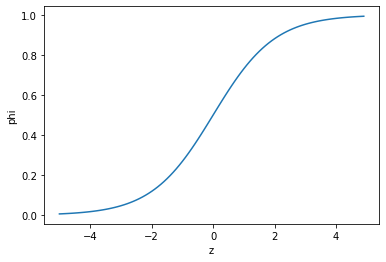

In [28]:
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)       # -5 <= z < 5 범위에 0.1간격으로 배열 생성
phi = 1 / (1 + np.exp(-z))      #  로지스틱 함수 수식
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [29]:
# 불리언 인덱싱
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [30]:
# 로지스틱 회귀로 이진분류 수행하기
# 도미(Bream)와 빙어(Smelt)만 추출
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

print(train_bream_smelt.shape)
print(bream_smelt_indexes)

(33, 5)
[ True False  True False False False False  True False False False  True
 False False False  True  True False False  True False  True False False
 False  True False False  True False False False False  True False False
  True  True False False False False False  True False False False False
 False  True False  True False False  True False False False  True False
 False False False False False  True False  True False False False False
 False False False False False  True False  True False False  True  True
 False False False  True False False False False False  True False False
 False  True False  True False False  True  True False False False False
 False False False False  True  True False False  True False False]


In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)       # 학습

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [32]:
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [33]:
# 확률 출력
# 첫번째 열이 음성클래스(0)에 대한 확률
# 두번째 열이 양성클래스(1)에 대한 확률
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99759855 0.00240145]
 [0.02735183 0.97264817]
 [0.99486072 0.00513928]
 [0.98584202 0.01415798]
 [0.99767269 0.00232731]]


In [34]:
# 사이킷런은 타겟값을 알파벳순으로 정렬
# Smelt가 양성클래스
print(lr.classes_)

['Bream' 'Smelt']


In [35]:
# 로지스틱 회귀도 선형 다항식을 사용한다
# z = -0.4037798*Weight + -0.57620209*Length + -0.66280298*Digonal
#     + -1.01290277*Height + -0.73168947*Width -2.16155132
print(lr.coef_, lr.intercept_)

[[-0.4037798  -0.57620209 -0.66280298 -1.01290277 -0.73168947]] [-2.16155132]


In [36]:
# z값을 출력
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02927744  3.57123907 -5.26568906 -4.24321775 -6.0607117 ]


In [37]:
# z값을 로지스틱 함수에 통과
# 양성 클래스와 일치
from scipy.special import expit
print(expit(decisions))
print([proba[1] for proba in lr.predict_proba(train_bream_smelt[:5])])

[0.00240145 0.97264817 0.00513928 0.01415798 0.00232731]
[0.002401451878047963, 0.9726481722467774, 0.005139283545591814, 0.014157979296024128, 0.0023273110833360597]


## 로지스틱 회귀로 다중 분류 수행

In [38]:
# C는 규제값, alpha와 반대로 작을수록 규제가 커진다
# C값을 주지 않으면 자동으로 1이 적용된다
# 릿지 회귀처럼 사용
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [39]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [40]:
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

[[0.    0.014 0.841 0.    0.136 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.935 0.015 0.016 0.   ]
 [0.011 0.034 0.306 0.007 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [41]:
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [42]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


## 이진 분류시 : 선형회귀 -> 로지스틱 함수
## 다중 분류시 : 선형회귀 -> exp함수 -> 소프트맥스 함수
- 소프트맥스에 각 클래스의 값을 모두 더하면 1이 된다
- 클래스마다 선형회귀를 통해서 z값을 계산
- 모두 각 클래스 값/전체 더한 값 => 전체에서 각 클래스의 비중
- ex) 1 3 4 2 => 1/10 3/10 4/10 2/10
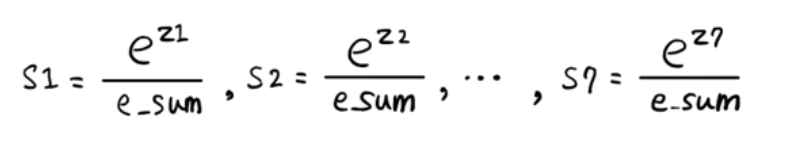
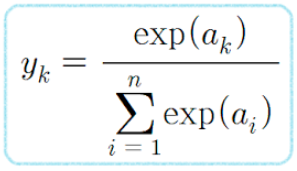

In [44]:
# z값을 출력(선형회귀 수식을 통과한 결과값)
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.5    1.03   5.16  -2.73   3.34   0.33  -0.63]
 [-10.86   1.93   4.77  -2.4    2.98   7.84  -4.26]
 [ -4.34  -6.23   3.17   6.49   2.36   2.42  -3.87]
 [ -0.68   0.45   2.65  -1.19   3.26  -5.75   1.26]
 [ -6.4   -1.99   5.82  -0.11   3.5   -0.11  -0.71]]


In [46]:
from scipy.special import softmax

# 여러 클래스의 모든 출력값을 더하면 1이된다
proba = softmax(decision, axis=1)
print(np.round(proba, decimals=3))

# 가장 큰 값이 확률이면서, 해당 클래스가 된다

[[0.    0.014 0.841 0.    0.136 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.935 0.015 0.016 0.   ]
 [0.011 0.034 0.306 0.007 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]
